# 日経平均株価 先物（CME日経先物 円建て）15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import os

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import pandas as pd
import yfinance as yf

In [3]:
symbol = "NIY=F"
ticker1 = yf.Ticker(symbol)
df = ticker1.history(period="1d", interval="15m")
df.index = df.index.tz_convert("Asia/Tokyo")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-07-06 13:00:00+09:00,69345.0,69360.0,69170.0,69360.0,226,0.0,0.0
2026-07-06 13:15:00+09:00,69350.0,69525.0,69325.0,69515.0,149,0.0,0.0
2026-07-06 13:30:00+09:00,69515.0,69660.0,69510.0,69640.0,250,0.0,0.0
2026-07-06 13:45:00+09:00,69610.0,69700.0,69540.0,69655.0,161,0.0,0.0
2026-07-06 14:00:00+09:00,69670.0,69700.0,69580.0,69680.0,130,0.0,0.0
2026-07-06 14:15:00+09:00,69680.0,69780.0,69460.0,69460.0,172,0.0,0.0
2026-07-06 14:30:00+09:00,69460.0,69700.0,69385.0,69665.0,192,0.0,0.0
2026-07-06 14:45:00+09:00,69645.0,69755.0,69525.0,69725.0,95,0.0,0.0
2026-07-06 15:00:00+09:00,69735.0,69775.0,69640.0,69660.0,92,0.0,0.0


In [4]:
# 先頭のタイムスタンプ（例：金曜のどこかの時刻）
dt0 = df.index[0]

# 金曜の日付だけを取り出す
fri = dt0.normalize()  # 00:00 に丸める

# 開始・終了
dt_start = fri + pd.Timedelta(hours=15, minutes=30)
dt_end = fri + pd.Timedelta(days=1, hours=6)
print(dt_start)
print(dt_end)

df = df[(dt_start <= df.index) & (df.index < dt_end)]
df

2026-07-06 15:30:00+09:00
2026-07-07 06:00:00+09:00


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-07-06 15:30:00+09:00,69900.0,70010.0,69870.0,69995.0,652,0.0,0.0
2026-07-06 15:45:00+09:00,69990.0,70000.0,69910.0,69960.0,210,0.0,0.0
2026-07-06 16:00:00+09:00,69955.0,69980.0,69830.0,69910.0,527,0.0,0.0
2026-07-06 16:15:00+09:00,69920.0,69975.0,69885.0,69915.0,331,0.0,0.0
2026-07-06 16:30:00+09:00,69905.0,69975.0,69890.0,69960.0,106,0.0,0.0
2026-07-06 16:45:00+09:00,69970.0,70095.0,69960.0,70065.0,315,0.0,0.0
2026-07-06 17:00:00+09:00,70055.0,70395.0,70045.0,70170.0,560,0.0,0.0
2026-07-06 17:15:00+09:00,70180.0,70195.0,70010.0,70060.0,119,0.0,0.0
2026-07-06 17:30:00+09:00,70050.0,70115.0,69990.0,70105.0,90,0.0,0.0


In [5]:
year_str = f"{dt_end.year:04d}"
month_str = f"{dt_end.month:02d}"
day_str = f"{dt_end.day:02d}"
output_path = os.path.join(year_str, month_str, day_str)
os.makedirs(output_path, exist_ok=True)
output_path

'2026/07/07'

## ローソク足チャート（小さいサイズ）

In [6]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

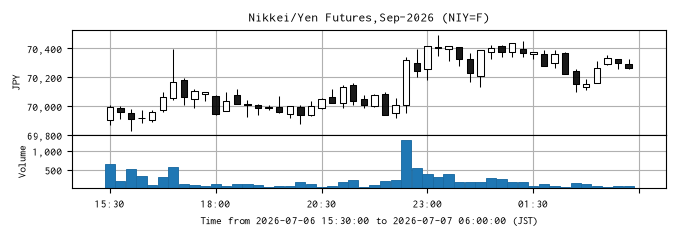

In [7]:
fig = plt.figure(figsize=(6.8, 2.4))
ax = dict()
n = 2
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[2 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()

mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    volume=ax[1],
    ax=ax[0],
)
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

ax[1].set_xlabel(
    f"Time from {dt_start.replace(tzinfo=None)} "
    f"to {dt_end.replace(tzinfo=None)} (JST)"
)
ax[0].set_ylabel("JPY")

if "shortName" in ticker1.info:
    ax[0].set_title(f"{ticker1.info['shortName']} ({symbol})")
elif "longName" in ticker1.info:
    ax[0].set_title(f"{ticker1.info['longName']} ({symbol})")
else:
    ax[0].set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(os.path.join(output_path, f"15min_chart_{symbol}.png"))
plt.show()